### **추가분석 1: 전체 교통사고 대비 PM 사고 비율 분석**

#### TAAS 연도별 엑셀의 전체 행 슬롯을 전체 교통사고 건수의 근사 분모로 보고, PM 사고가 전체 사고에서 차지하는 비중을 확인합니다.

> 주의: 해당 TAAS 엑셀은 비PM 사고 행이 비어 있고 PM 사고 행만 값이 남아 있는 구조로 보입니다. 따라서 `전체교통사고_행수추정`은 원본 행 위치가 유지되었다는 전제에서 사용하는 보조 지표입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = Path(r'N:/개인/대학교/2026/고급프로그래밍/Term-Project(고급프로그래밍설계 01분반 10조)')


In [2]:
import openpyxl

taas_dir = BASE_PATH / '전체 데이터셋/교통사고 분석 시스템(TAAS)'
pm_month = pd.read_csv(BASE_PATH / '데이터 전처리/서울시 PM 교통사고 현황/서울시_자치구별_월별_PM교통사고.csv', encoding='utf-8')

rows = []
for xlsx in sorted(taas_dir.glob('*.xlsx')):
    wb = openpyxl.load_workbook(xlsx, read_only=True, data_only=True)
    ws = wb[wb.sheetnames[0]]
    total_slots, pm_records = 0, 0
    for row in ws.iter_rows(min_row=2, values_only=True):
        total_slots += 1
        if any(v is not None for v in row):
            pm_records += 1
    rows.append({
        '연도': int(xlsx.stem),
        'TAAS_전체교통사고_행수추정': total_slots,
        'PM_사고건수_TAAS': pm_records,
        'PM_비율(%)': pm_records / total_slots * 100
    })

ratio = pd.DataFrame(rows)
pm_year = pm_month.groupby('연도', as_index=False)['PM_사고건수'].sum()
ratio = ratio.merge(pm_year, on='연도', how='left').rename(columns={'PM_사고건수': '전처리_PM_사고건수'})
ratio['PM_비율_전년대비증감(pp)'] = ratio['PM_비율(%)'].diff()
ratio['PM사고_전년대비증감률(%)'] = ratio['PM_사고건수_TAAS'].pct_change() * 100
display(ratio)


,연도,TAAS_전체교통사고_행수추정,PM_사고건수_TAAS,PM_비율(%),전처리_PM_사고건수,PM_비율_전년대비증감(pp),PM사고_전년대비증감률(%)
0,2019,39258,236,0.601151,236,NaN,NaN
1,2020,35227,575,1.632271,575,1.031119,143.644068
2,2021,33913,640,1.887182,640,0.254911,11.304348
3,2022,33698,581,1.724138,581,-0.163044,-9.218750
4,2023,33811,668,1.975688,668,0.251550,14.974182
5,2024,33465,646,1.930375,646,-0.045313,-3.293413


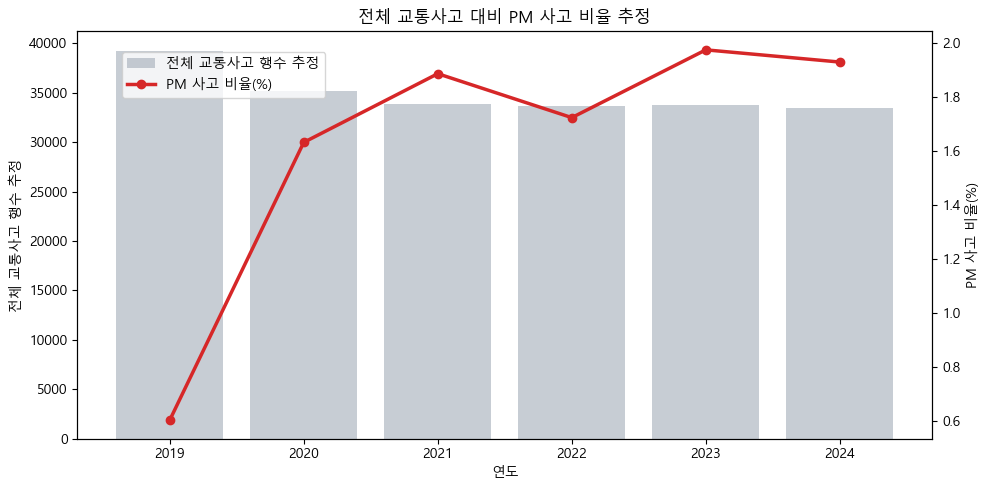

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(ratio['연도'], ratio['TAAS_전체교통사고_행수추정'], color='#9aa4b2', alpha=0.55, label='전체 교통사고 행수 추정')
ax1.set_ylabel('전체 교통사고 행수 추정')
ax2 = ax1.twinx()
ax2.plot(ratio['연도'], ratio['PM_비율(%)'], marker='o', linewidth=2.5, color='#d62728', label='PM 사고 비율(%)')
ax2.set_ylabel('PM 사고 비율(%)')
ax1.set_title('전체 교통사고 대비 PM 사고 비율 추정')
ax1.set_xlabel('연도')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.9))
plt.tight_layout()
plt.show()


#### 결과 요약

| 연도 | TAAS_전체교통사고_행수추정 | PM_사고건수_TAAS | PM_비율(%) | PM_비율_전년대비증감(pp) |
| --- | --- | --- | --- | --- |
| 2019.00 | 39258.00 | 236.00 | 0.60 |  |
| 2020.00 | 35227.00 | 575.00 | 1.63 | 1.03 |
| 2021.00 | 33913.00 | 640.00 | 1.89 | 0.25 |
| 2022.00 | 33698.00 | 581.00 | 1.72 | -0.16 |
| 2023.00 | 33811.00 | 668.00 | 1.98 | 0.25 |
| 2024.00 | 33465.00 | 646.00 | 1.93 | -0.05 |

- PM 사고 비율은 2019년 0.60%에서 2024년 1.93%로 상승했습니다.
- 전체 교통사고 규모가 완만히 줄어드는 동안 PM 사고는 증가했기 때문에, 단순 사고 건수뿐 아니라 전체 사고 내 비중도 커진 것으로 해석할 수 있습니다.
- 다만 이 결과는 TAAS 엑셀의 비어 있는 행을 전체 사고 행 슬롯으로 보는 전제에 기반하므로, 보고서에는 `추정 비율` 또는 `TAAS 원본 행 구조 기반 비율`로 표현하는 것이 안전합니다.